# $(SASA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
95,22,2,"(0.01, 1.0)","(-0.112, -1.152, 0.086, 0.859)",1,1.0,"(-0.135, -0.964, 0.104, 0.735)",0.0,1.0,"(-0.155, -1.153, 0.118, 0.887)"
251,25,9,"(0.92, 0.9)","(-0.016, -0.199, -0.007, -0.059)",0,1.0,"(-0.02, -0.399, -0.008, 0.344)",0.0,1.0,"(-0.028, -0.6, -0.001, 0.747)"
42,42,0,"(0.18, 1.6)","(-0.039, 1.054, 0.195, -0.073)",0,1.0,"(-0.018, 0.867, 0.194, 0.042)",0.0,1.0,"(-0.001, 0.68, 0.195, 0.157)"
113,12,3,"(0.63, 1.6)","(-0.131, -0.785, 0.105, 0.693)",1,1.0,"(-0.147, -0.597, 0.119, 0.562)",1.0,1.0,"(-0.159, -0.409, 0.13, 0.434)"
2,2,0,"(0.18, 1.6)","(0.037, -0.414, 0.018, 0.222)",0,1.0,"(0.029, -0.6, 0.022, 0.321)",1.0,1.0,"(0.017, -0.414, 0.029, 0.226)"
...,...,...,...,...,...,...,...,...,...,...
26,26,0,"(0.18, 1.6)","(-0.118, 0.322, 0.135, 0.039)",1,1.0,"(-0.112, 0.507, 0.136, -0.043)",0.0,1.0,"(-0.102, 0.32, 0.135, 0.067)"
167,20,5,"(0.43, 0.0)","(0.065, 0.024, -0.017, 0.138)",1,1.0,"(0.066, 0.223, -0.014, -0.255)",1.0,1.0,"(0.07, 0.423, -0.019, -0.647)"
156,9,5,"(0.43, 0.0)","(0.012, 0.226, 0.048, -0.315)",1,1.0,"(0.016, 0.424, 0.042, -0.68)",0.0,1.0,"(0.025, 0.224, 0.028, -0.277)"
232,6,9,"(0.92, 0.9)","(0.079, 0.381, -0.075, -0.819)",0,1.0,"(0.086, 0.182, -0.092, -0.45)",0.0,1.0,"(0.09, -0.016, -0.101, -0.09)"


In [ ]:
model = Base_Line_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([259, 4])) that is different to the input size (torch.Size([4])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


,epoch,mse_s,transition,reward
0,0,"[0.1780492067337036, 0.4337812662124634, 0.011...",1.299521,0.181301
1,1,"[0.17011085152626038, 0.4313184320926666, 0.01...",1.287807,0.181580
2,2,"[0.16235901415348053, 0.42895829677581787, 0.0...",1.276496,0.181862
3,3,"[0.15479478240013123, 0.42670100927352905, 0.0...",1.265593,0.182148
4,4,"[0.14741908013820648, 0.4245467483997345, 0.01...",1.255098,0.182437


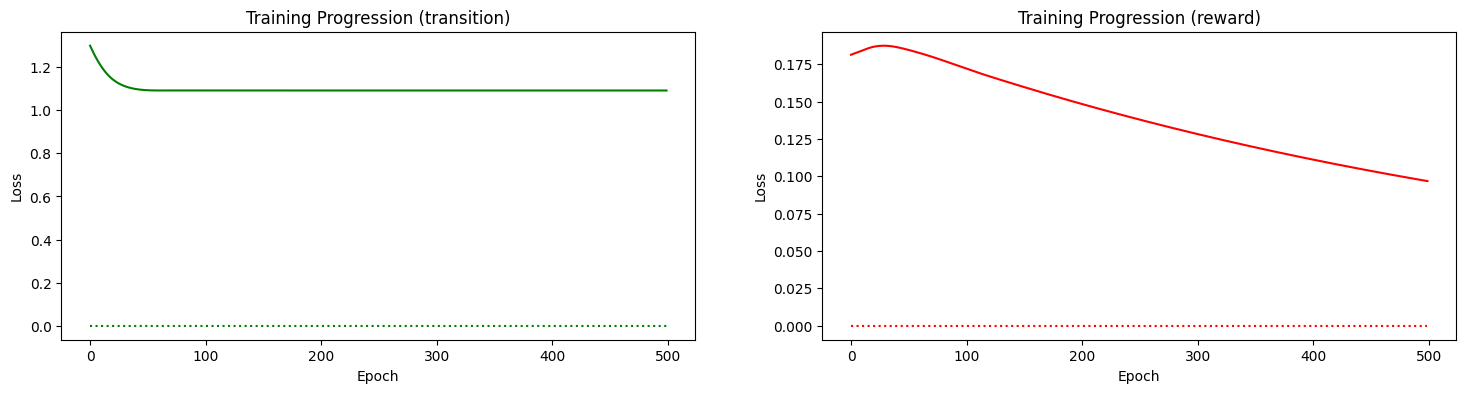

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

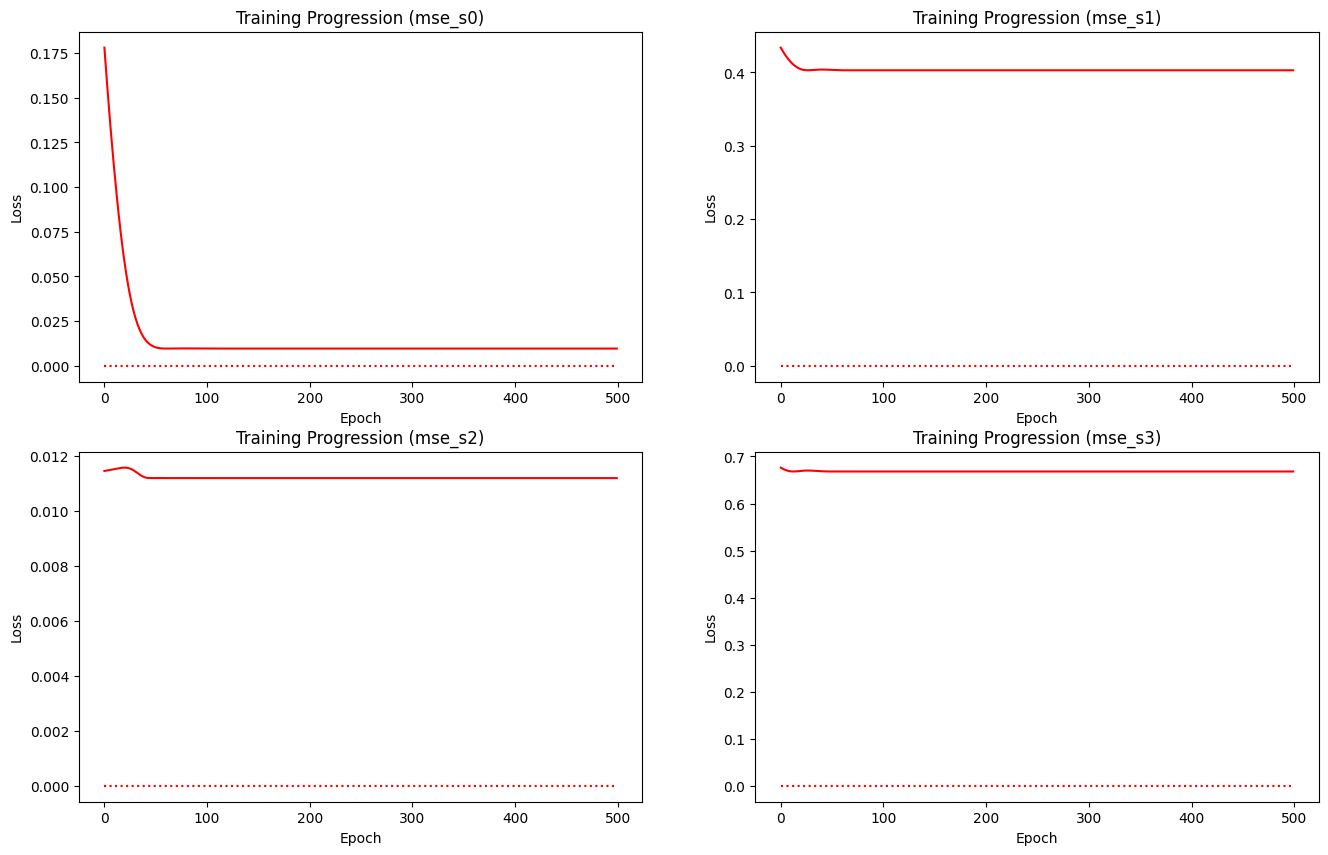

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [6]:
results = data.evaluate_model(model, path='testing_data.csv')
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_r
0,0,0,"(0.49, 0.0)","(0.005, 0.039, -0.028, -0.013)",1,1.0,"(0.006, 0.24, -0.028, -0.434)",1.0,1.0,"(0.011, 0.441, -0.037, -0.856)","(-0.027, 0.182, -0.056, -0.192)",0.7
1,1,0,"(0.49, 0.0)","(0.006, 0.24, -0.028, -0.434)",1,1.0,"(0.011, 0.441, -0.037, -0.856)",0.0,1.0,"(0.019, 0.241, -0.054, -0.463)","(-0.037, 0.24, 0.032, -0.189)",0.7
2,2,0,"(0.49, 0.0)","(0.011, 0.441, -0.037, -0.856)",0,1.0,"(0.019, 0.241, -0.054, -0.463)",1.0,1.0,"(0.024, 0.442, -0.063, -0.896)","(-0.099, 0.018, 0.089, -0.21)",0.7
3,3,0,"(0.49, 0.0)","(0.019, 0.241, -0.054, -0.463)",1,1.0,"(0.024, 0.442, -0.063, -0.896)",1.0,1.0,"(0.033, 0.644, -0.081, -1.331)","(-0.057, 0.18, -0.03, -0.234)",0.7
4,4,0,"(0.49, 0.0)","(0.024, 0.442, -0.063, -0.896)",1,1.0,"(0.033, 0.644, -0.081, -1.331)",1.0,1.0,"(0.046, 0.846, -0.108, -1.774)","(-0.084, 0.172, -0.007, -0.267)",0.7


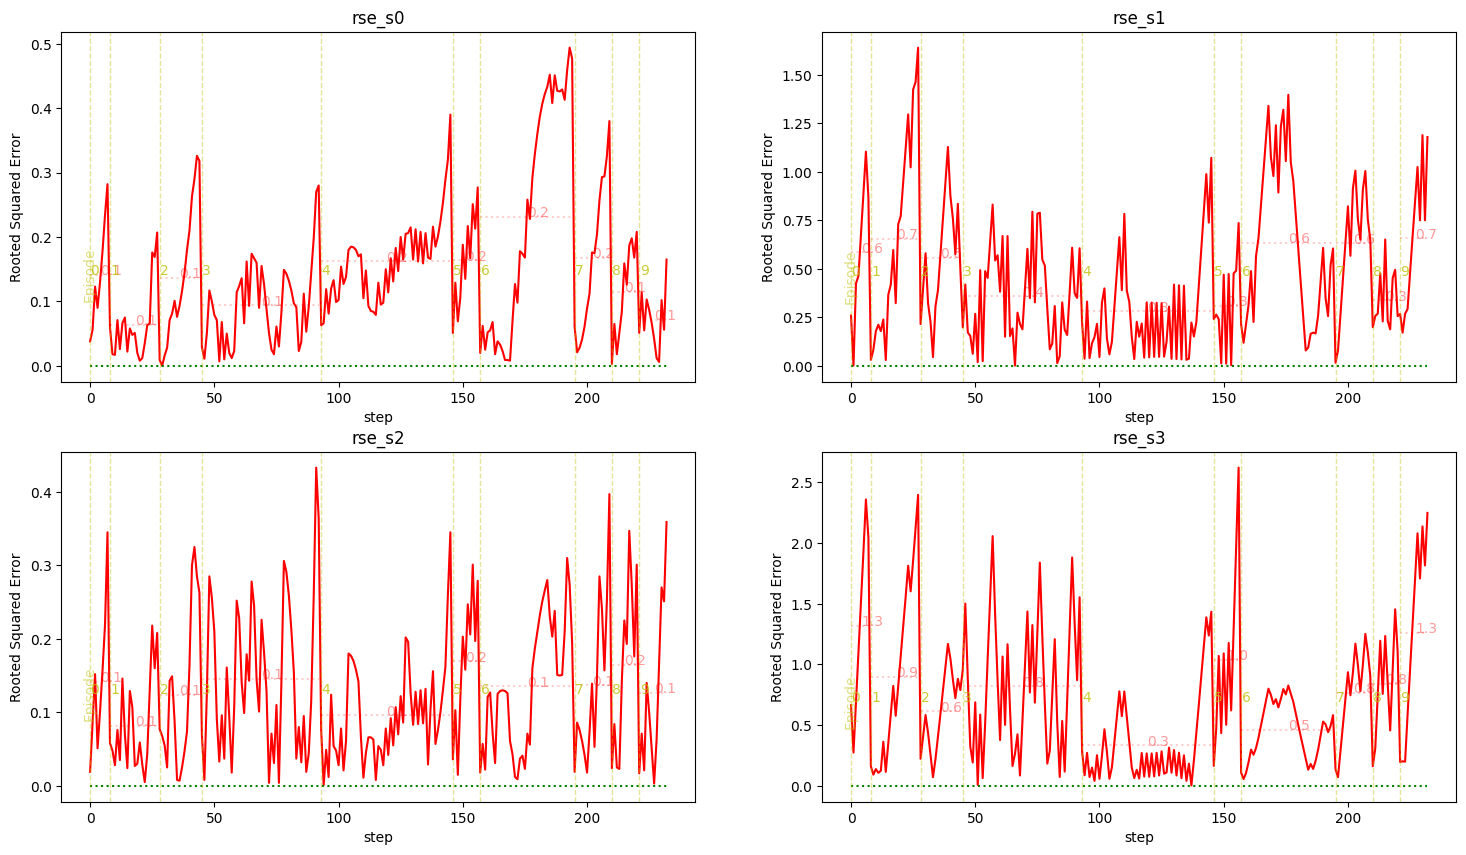

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

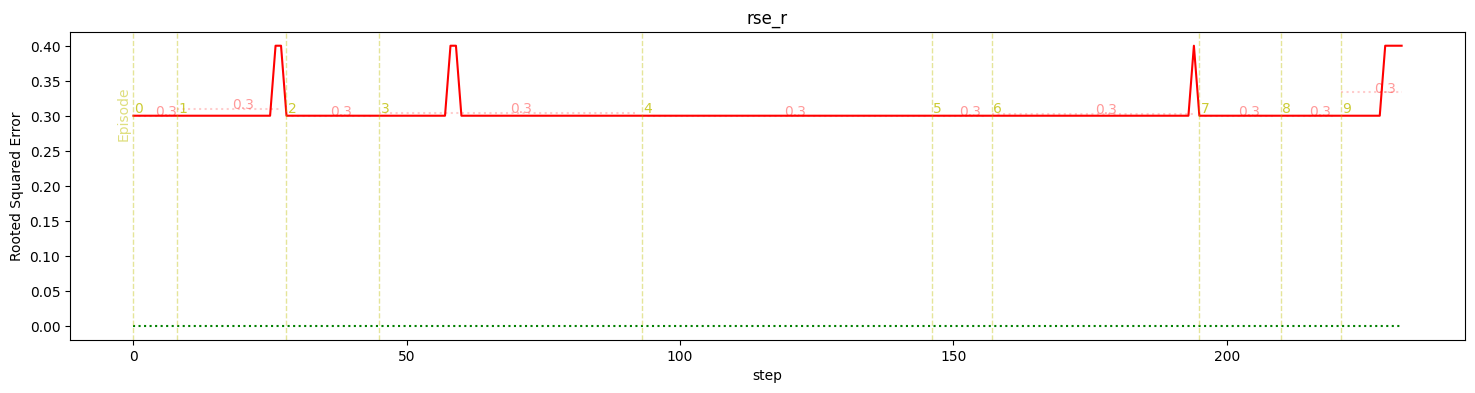

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

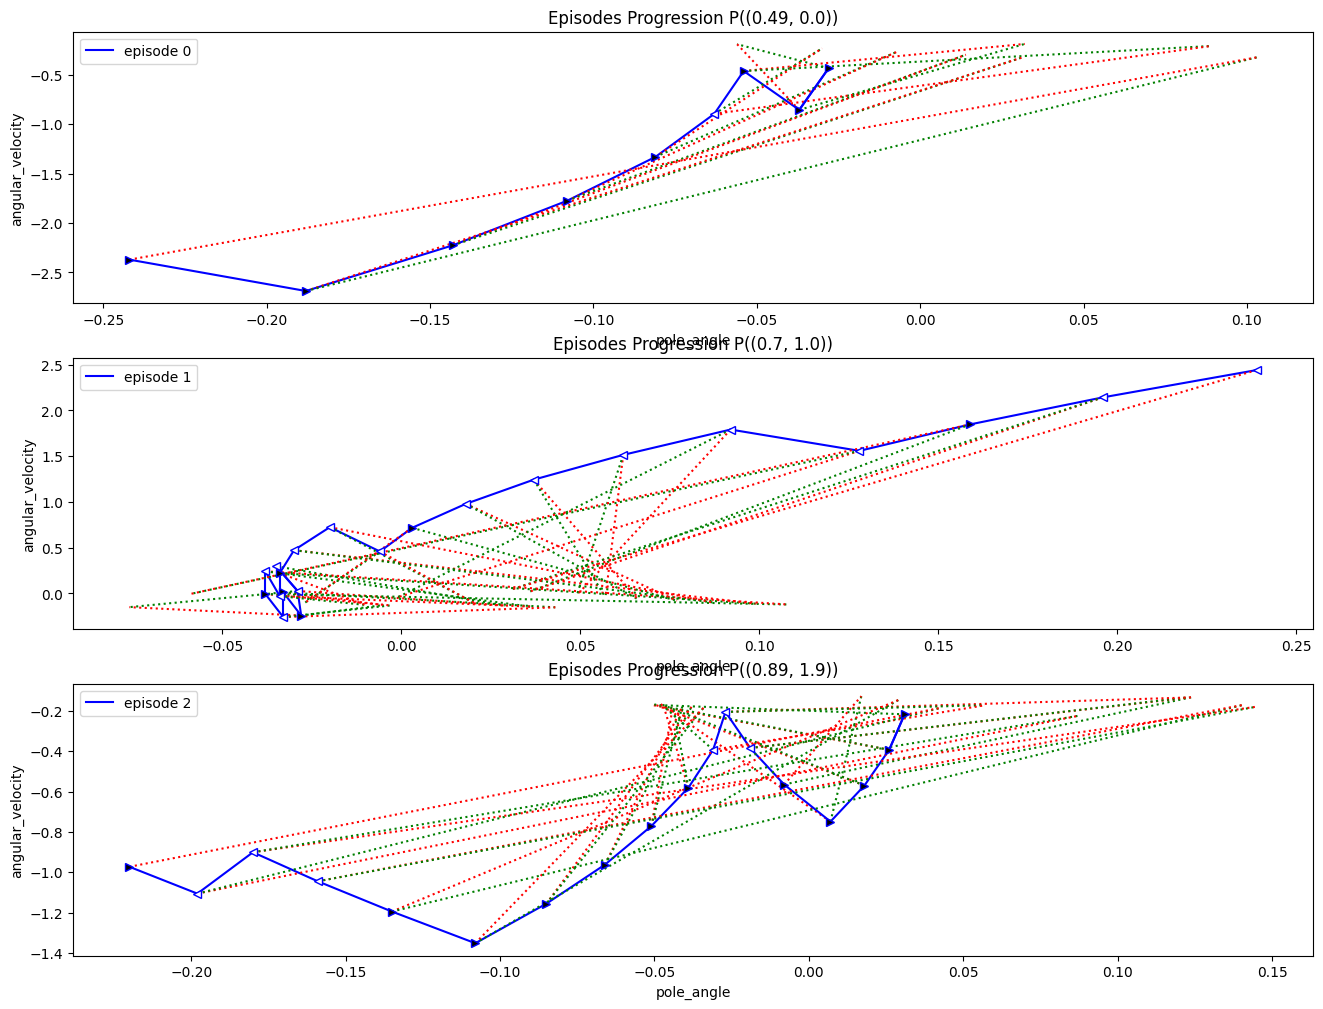

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()